# Specs — A-Class EDA

Profiles `data/external/mercedes_specs_A_class.csv` (scraped spec sheet, one row per A-Class variant) before it is used to enrich the resale pool.

Focus: **(1) duplicate rows** and **(2) rows with too much missing data**.

In [1]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = pathlib.Path.cwd()
while not (ROOT / 'data' / 'external').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CSV_PATH = ROOT / 'data' / 'external' / 'mercedes_specs_A_class.csv'

sns.set_theme()
pd.set_option('display.max_columns', 60)

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(155, 44)


,model_family,generation,model_page_title,version_name,year_start,year_end,body,num_doors,engine_type,engine_code,fuel_type,fuel_system,engine_alignment,displacement_cc,num_valves,aspiration,compression_ratio,horsepower_hp,torque_nm,drive_wheels,transmission,top_speed_kmh,accel_0_100_s,consumption_city_l100km,consumption_openroad_l100km,consumption_combined_l100km,range_km,fuel_tank_l,total_electric_power_hp,total_electric_torque_nm,num_electric_engines,electric_engine_type,front_axle_power_hp,front_axle_torque_nm,avg_energy_consumption,battery_type,battery_voltage,battery_capacity_kwh,charging_dc,charging_wallbox,charging_ac,fast_charge_current,source_url,scraped_at
0,A Class,W177 Facelift (2022 - Present),Class A (W177 2023),Mercedes Benz Class A (W177 2023) 250e 8G-DCT,2023.0,2024.0,Hatchback,5,Inline 4,282814,Plug-In Hybrid / Petrol,Direct Injection,Transverse,1332,16,Turbo Intercooler,10.6,163,250,FWD,8 speed Dualclutch Automatic,225.0,7.4,NaN,NaN,0.8,NaN,35.0,109.0,300.0,1.0,NaN,NaN,NaN,NaN,Lithium-ion,NaN,15.6,Charging Time,NaN,NaN,22.0 kW,https://www.ultimatespecs.com/car-specs/Merced...,2026-07-04T16:47:18.444571
1,A Class,W177 Facelift (2022 - Present),Class A (W177 2023),Mercedes Benz Class A (W177 2023) 180 7G-DCT,2022.0,2024.0,Hatchback,5,Inline 4,NaN,Mild Hybrid / Petrol,Direct Injection,Transverse,1332,16,Turbo Intercooler,NaN,150,230,FWD,7 speed Dualclutch Automatic,215.0,9.2,NaN,NaN,5.8,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ultimatespecs.com/car-specs/Merced...,2026-07-04T16:50:33.395686
2,A Class,W177 Facelift (2022 - Present),Class A (W177 2023),Mercedes Benz Class A (W177 2023) 180 7G-DCT,2025.0,2026.0,Hatchback,5,Inline 4,M282.814,Mild Petrol,Direct Injection,Transverse,1332,16,Turbo Intercooler,10.6,136,230,FWD,7 speed Dualclutch Automatic,215.0,9.2,NaN,NaN,5.8,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ultimatespecs.com/car-specs/Merced...,2026-07-04T16:51:09.783657
3,A Class,W177 Facelift (2022 - Present),Class A (W177 2023),Mercedes Benz Class A (W177 2023) 200 7G-DCT,2022.0,2024.0,Hatchback,5,Inline 4,NaN,Mild Hybrid / Petrol,Direct Injection,Transverse,1332,16,Turbo Intercooler,NaN,177,270,FWD,7 speed Dualclutch Automatic,225.0,8.2,NaN,NaN,5.8,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ultimatespecs.com/car-specs/Merced...,2026-07-04T17:10:29.988000
4,A Class,W177 Facelift (2022 - Present),Class A (W177 2023),Mercedes Benz Class A (W177 2023) 200 7G-DCT,2025.0,2026.0,Hatchback,5,Inline 4,M282.814,Mild Petrol,Direct Injection,Transverse,1332,16,Turbo Intercooler,10.6,163,270,FWD,7 speed Dualclutch Automatic,225.0,8.2,NaN,NaN,5.8,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ultimatespecs.com/car-specs/Merced...,2026-07-04T17:11:06.800570


## Shape & dtypes

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   model_family                 155 non-null    object 
 1   generation                   155 non-null    object 
 2   model_page_title             155 non-null    object 
 3   version_name                 155 non-null    object 
 4   year_start                   124 non-null    float64
 5   year_end                     124 non-null    float64
 6   body                         120 non-null    object 
 7   num_doors                    155 non-null    int64  
 8   engine_type                  155 non-null    object 
 9   engine_code                  53 non-null     object 
 10  fuel_type                    155 non-null    object 
 11  fuel_system                  141 non-null    object 
 12  engine_alignment             153 non-null    object 
 13  displacement_cc     

## Duplicate rows

Three lenses, from strictest to most meaningful:
1. **Exact** full-row duplicates.
2. Duplicates ignoring `source_url` / `scraped_at` — these two columns are scrape metadata and will always be unique even if every spec value is identical.
3. Duplicates on the **business key** (`version_name`, `year_start`, `year_end`) — the same trim/year combination scraped more than once.

In [3]:
print('exact duplicate rows:', df.duplicated().sum())

meta_cols = ['source_url', 'scraped_at']
spec_cols = [c for c in df.columns if c not in meta_cols]
spec_dupes = df.duplicated(subset=spec_cols, keep=False)
print('duplicate rows ignoring source_url/scraped_at:', spec_dupes.sum())
df.loc[spec_dupes].sort_values('version_name')

exact duplicate rows: 0
duplicate rows ignoring source_url/scraped_at: 0


,model_family,generation,model_page_title,version_name,year_start,year_end,body,num_doors,engine_type,engine_code,fuel_type,fuel_system,engine_alignment,displacement_cc,num_valves,aspiration,compression_ratio,horsepower_hp,torque_nm,drive_wheels,transmission,top_speed_kmh,accel_0_100_s,consumption_city_l100km,consumption_openroad_l100km,consumption_combined_l100km,range_km,fuel_tank_l,total_electric_power_hp,total_electric_torque_nm,num_electric_engines,electric_engine_type,front_axle_power_hp,front_axle_torque_nm,avg_energy_consumption,battery_type,battery_voltage,battery_capacity_kwh,charging_dc,charging_wallbox,charging_ac,fast_charge_current,source_url,scraped_at


In [4]:
key_cols = ['version_name', 'year_start', 'year_end']
key_dupes = df.duplicated(subset=key_cols, keep=False)
print('duplicate rows on (version_name, year_start, year_end):', key_dupes.sum())
df.loc[key_dupes, key_cols].sort_values(key_cols)

duplicate rows on (version_name, year_start, year_end): 0


,version_name,year_start,year_end


## Missing values — by column

Which fields are sparsest. Expect the EV/hybrid-only fields (`battery_*`, `charging_*`, `total_electric_*`) to be mostly blank since most A-Class variants are pure ICE.

In [5]:
col_missing = (df.isna().mean() * 100).sort_values(ascending=False)
col_missing = col_missing[col_missing > 0]
print(f'{len(col_missing)} of {df.shape[1]} columns have at least one missing value')
col_missing

26 of 44 columns have at least one missing value


charging_ac                    100.000000
front_axle_power_hp            100.000000
charging_wallbox               100.000000
battery_voltage                100.000000
front_axle_torque_nm           100.000000
avg_energy_consumption          99.354839
battery_capacity_kwh            98.064516
electric_engine_type            98.064516
fast_charge_current             97.419355
charging_dc                     96.774194
total_electric_torque_nm        96.129032
num_electric_engines            96.129032
total_electric_power_hp         96.129032
battery_type                    96.129032
engine_code                     65.806452
consumption_openroad_l100km     60.645161
consumption_city_l100km         60.645161
range_km                        28.387097
body                            22.580645
year_start                      20.000000
year_end                        20.000000
fuel_system                      9.032258
compression_ratio                7.096774
engine_alignment                 1

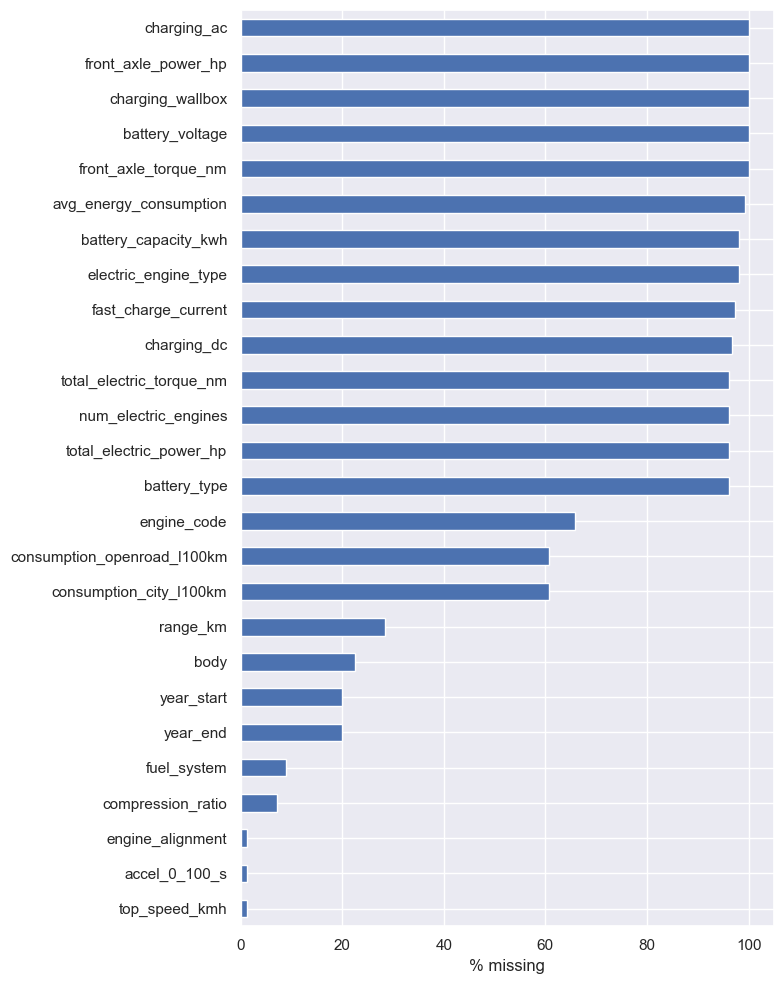

In [6]:
fig, ax = plt.subplots(figsize=(8, 10))
col_missing.plot.barh(ax=ax)
ax.set_xlabel('% missing')
ax.invert_yaxis()
plt.tight_layout()

## Missing values — by row

How much of *each row* is missing, and how many rows cross a "too much missing data" threshold. Adjust `THRESHOLD` below to test a stricter or looser cut.

count    155.000000
mean      38.005865
std        4.132150
min       20.454545
25%       36.363636
50%       38.636364
75%       40.909091
max       47.727273
dtype: float64


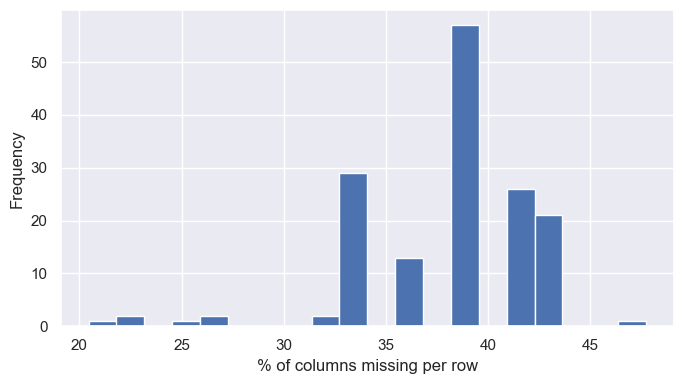

In [7]:
row_missing_pct = df.isna().mean(axis=1) * 100
print(row_missing_pct.describe())

fig, ax = plt.subplots(figsize=(7, 4))
row_missing_pct.plot.hist(bins=20, ax=ax)
ax.set_xlabel('% of columns missing per row')
plt.tight_layout()

In [8]:
for threshold in (30, 50, 70):
    n = (row_missing_pct > threshold).sum()
    print(f'rows with >{threshold}% missing: {n} ({n / len(df) * 100:.1f}%)')

THRESHOLD = 50
flagged = df.loc[row_missing_pct > THRESHOLD]
print(f'\nrows flagged at >{THRESHOLD}% missing: {len(flagged)}')
flagged

rows with >30% missing: 149 (96.1%)
rows with >50% missing: 0 (0.0%)
rows with >70% missing: 0 (0.0%)

rows flagged at >50% missing: 0


,model_family,generation,model_page_title,version_name,year_start,year_end,body,num_doors,engine_type,engine_code,fuel_type,fuel_system,engine_alignment,displacement_cc,num_valves,aspiration,compression_ratio,horsepower_hp,torque_nm,drive_wheels,transmission,top_speed_kmh,accel_0_100_s,consumption_city_l100km,consumption_openroad_l100km,consumption_combined_l100km,range_km,fuel_tank_l,total_electric_power_hp,total_electric_torque_nm,num_electric_engines,electric_engine_type,front_axle_power_hp,front_axle_torque_nm,avg_energy_consumption,battery_type,battery_voltage,battery_capacity_kwh,charging_dc,charging_wallbox,charging_ac,fast_charge_current,source_url,scraped_at


## Summary

- **Duplicates:** none found under any of the three checks above — each row is a distinct `version_name` + year-range combination.
- **Missingness:** column-level gaps are concentrated in EV/hybrid-only fields, which is expected for ICE variants rather than a data-quality problem. Row-level missing % stays well clear of a 50% threshold, so no rows currently need to be dropped for missingness alone — re-run after the next scrape to confirm this still holds.